In [ ]:
import networkx as nx
import numpy as np
#import community.community_louvain
import community as community_louvain
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def draw_graph(graph, title="", mylabels={}):
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2)
    plt.figure(1,figsize=(25,45))
    nx.draw(graph,
        pos = pos,
        node_color='pink',
        node_size=4000,
        #labels=mylabels,
        with_labels=True,
        font_size = 16,
        font_color='black')
    plt.title(label=title, fontsize=40, color="green")
    edge_labels = dict([((n1, n2), d['rel_type'])#
                    for n1, n2, d in graph.edges(data=True)])
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=20, font_weight='bold')
    plt.show()

In [ ]:
def draw_community(graph, partitionGraph, title=""):
    plt.figure(1,figsize=(25,70))
    
    shapes = 'so^>v<dph.12348P*hH+xXD|,so^>v<dph.'
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2) 
    cmap = cm.get_cmap('viridis', max(partitionGraph.values()) + 1)
    
    for node, clstr in partitionGraph.items():
        nx.draw_networkx_nodes(partitionGraph, pos, [node], node_size=2000, 
                               node_color=[cmap.colors[clstr]], 
                               node_shape=shapes[clstr])
    
    nx.draw_networkx_labels(graph,pos, font_size=12,font_family='sans-serif')
    
    nx.draw_networkx_edges(graph, pos, alpha=0.5)
    edge_labels = dict([((n1, n2), d['rel_type']) for n1, n2, d in graph.edges(data=True)])    
    nx.draw_networkx_edge_labels(partitionGraph, pos, edge_labels=edge_labels, label_pos=0.5, font_color='green', font_size=12, font_weight='normal')
    
    
    plt.title(label=title, fontsize=40, color="green")
    plt.show()

## 1. Athena

In [ ]:
H = nx.read_graphml('GL10appsDataGraphs/athena.gml')
G = nx.Graph(H) # create an undirected graph G from a directed graph H

G.number_of_edges() #184
G.number_of_nodes() #102

In [ ]:
draw_graph(G,"Graph without clusters",None)

### 1.1 Louvain Community (best partition)

In [20]:
# compute the best partition
#community.best_partition(graph, partition=None, weight=’weight’, resolution=1.0, randomize= None, random_state=None)
partition = community_louvain.best_partition(G)
#print(partition)
#print("max partition values", max(partition.values()))
#print("total", len(partition.values()))
#print(partition.keys())

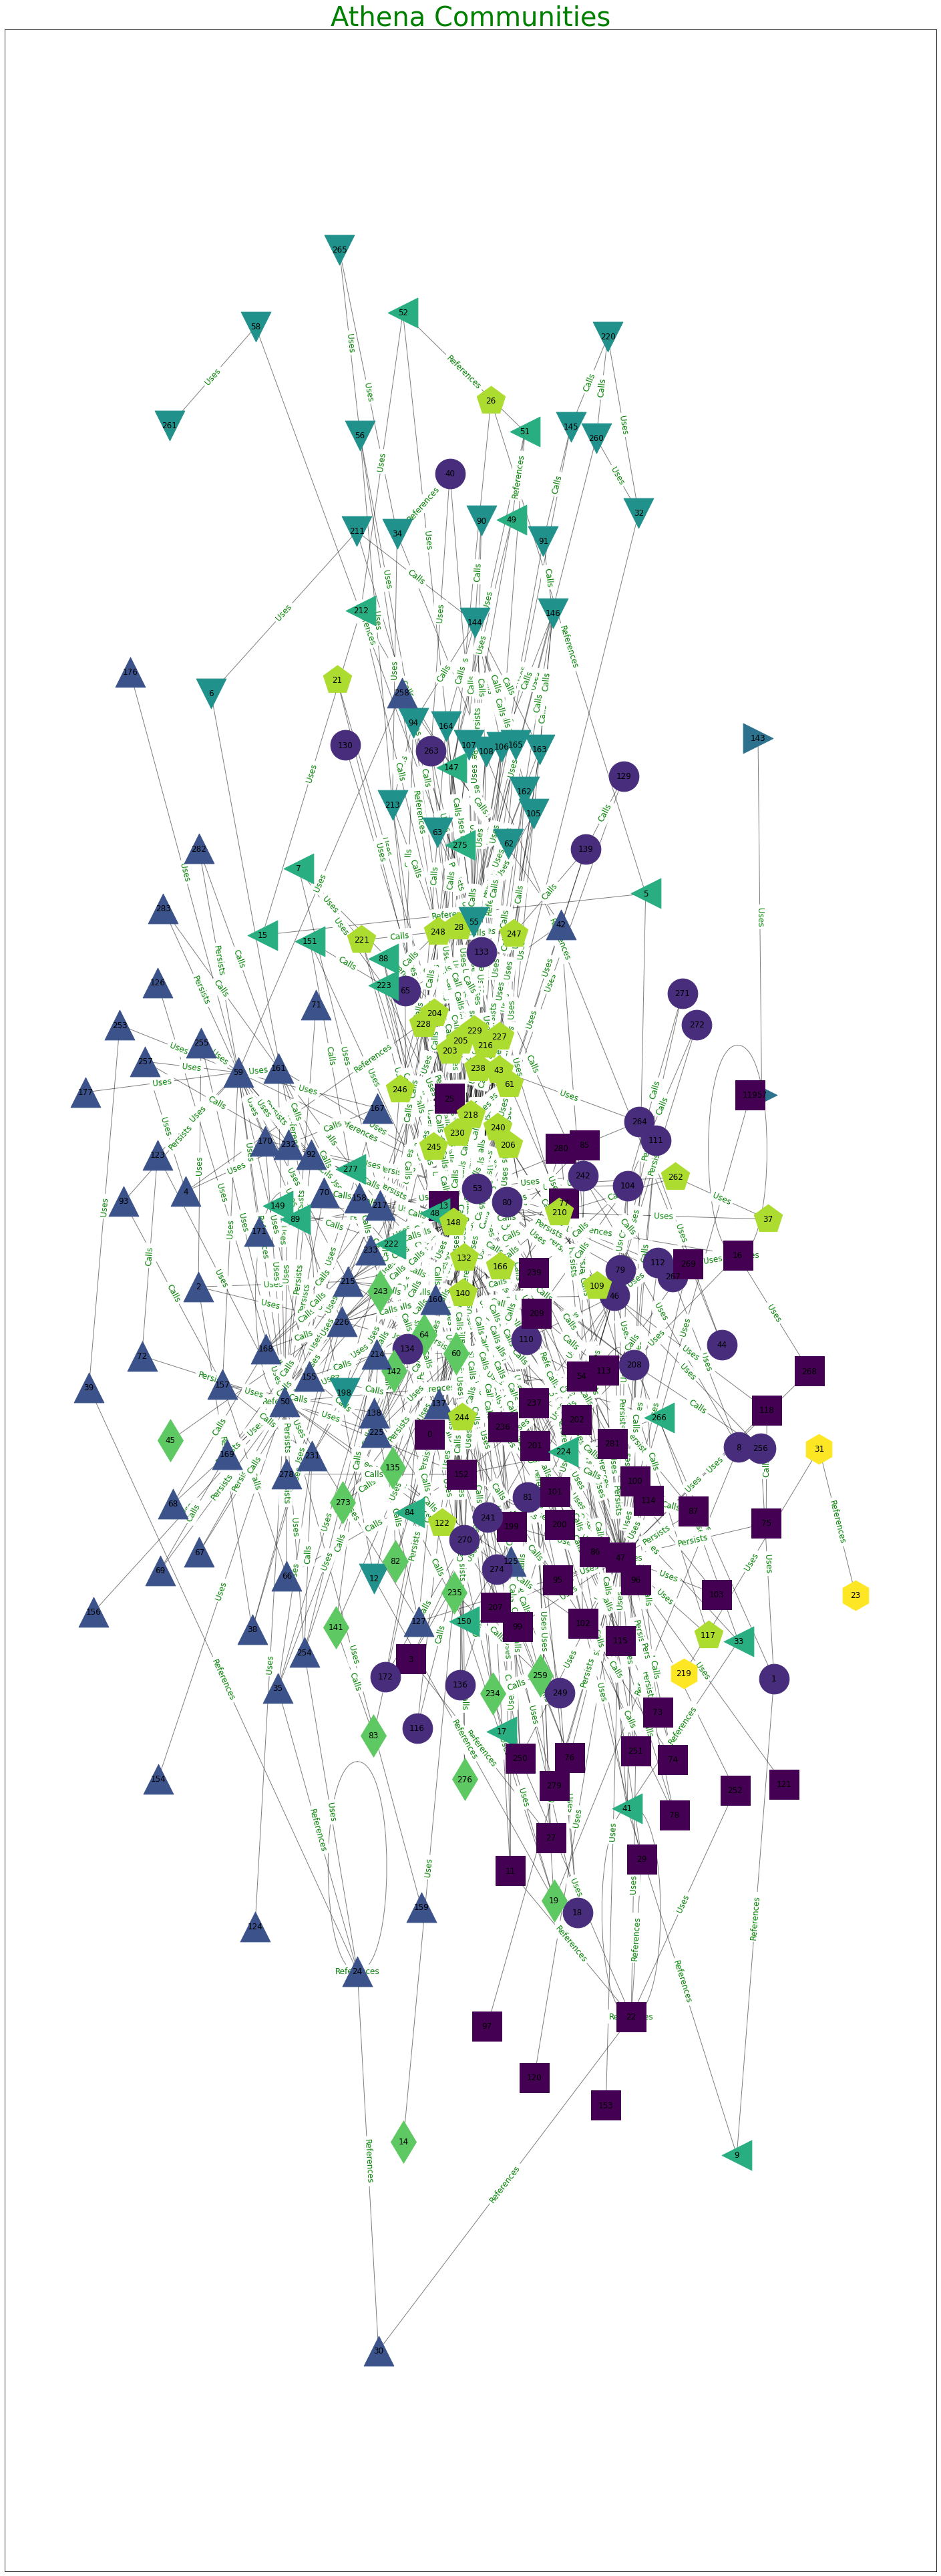

In [21]:
draw_community(G,partition,"Athena Communities")

#### 1.1.1 Write best-partition to excel

In [ ]:
partition_df = pd.DataFrame([partition])
#print (partition_df)
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-community-all.xlsx') as writer:  
    partition_df.to_excel(writer, sheet_name='Athena')

In [ ]:
#import json
#with open('GL10appsDataGraphs/athena-community.csv', 'w') as convert_file:
 #       convert_file.write(json.dumps(partition))

 ### 1.2 Louvain Community Dendogram

In [ ]:
#community.generate_dendrogram(graph, part_init=None, weight=’weight’, resolution=1.0, randomize=None, random_state=None)
athenaDendo = community_louvain.generate_dendrogram(G)

In [ ]:
len(athenaDendo)

In [ ]:
#print the dendogram cluster wrt each level
for level in range(len(athenaDendo)) :
    print("partition at level", level, "is", community_louvain.partition_at_level(athenaDendo, level), "\n")

 #### 1.2.1 Louvain community - get each level from dendogram

In [15]:
#Level 0
athenaPart0 = community_louvain.partition_at_level(athenaDendo, 0)


In [16]:
#Level 1
athenaPart1 = community_louvain.partition_at_level(athenaDendo, 1)

In [ ]:
#Level 2
athenaPart2 = community_louvain.partition_at_level(athenaDendo, 2)

#### 1.2.2 Louvain community - draw each level from dendogram

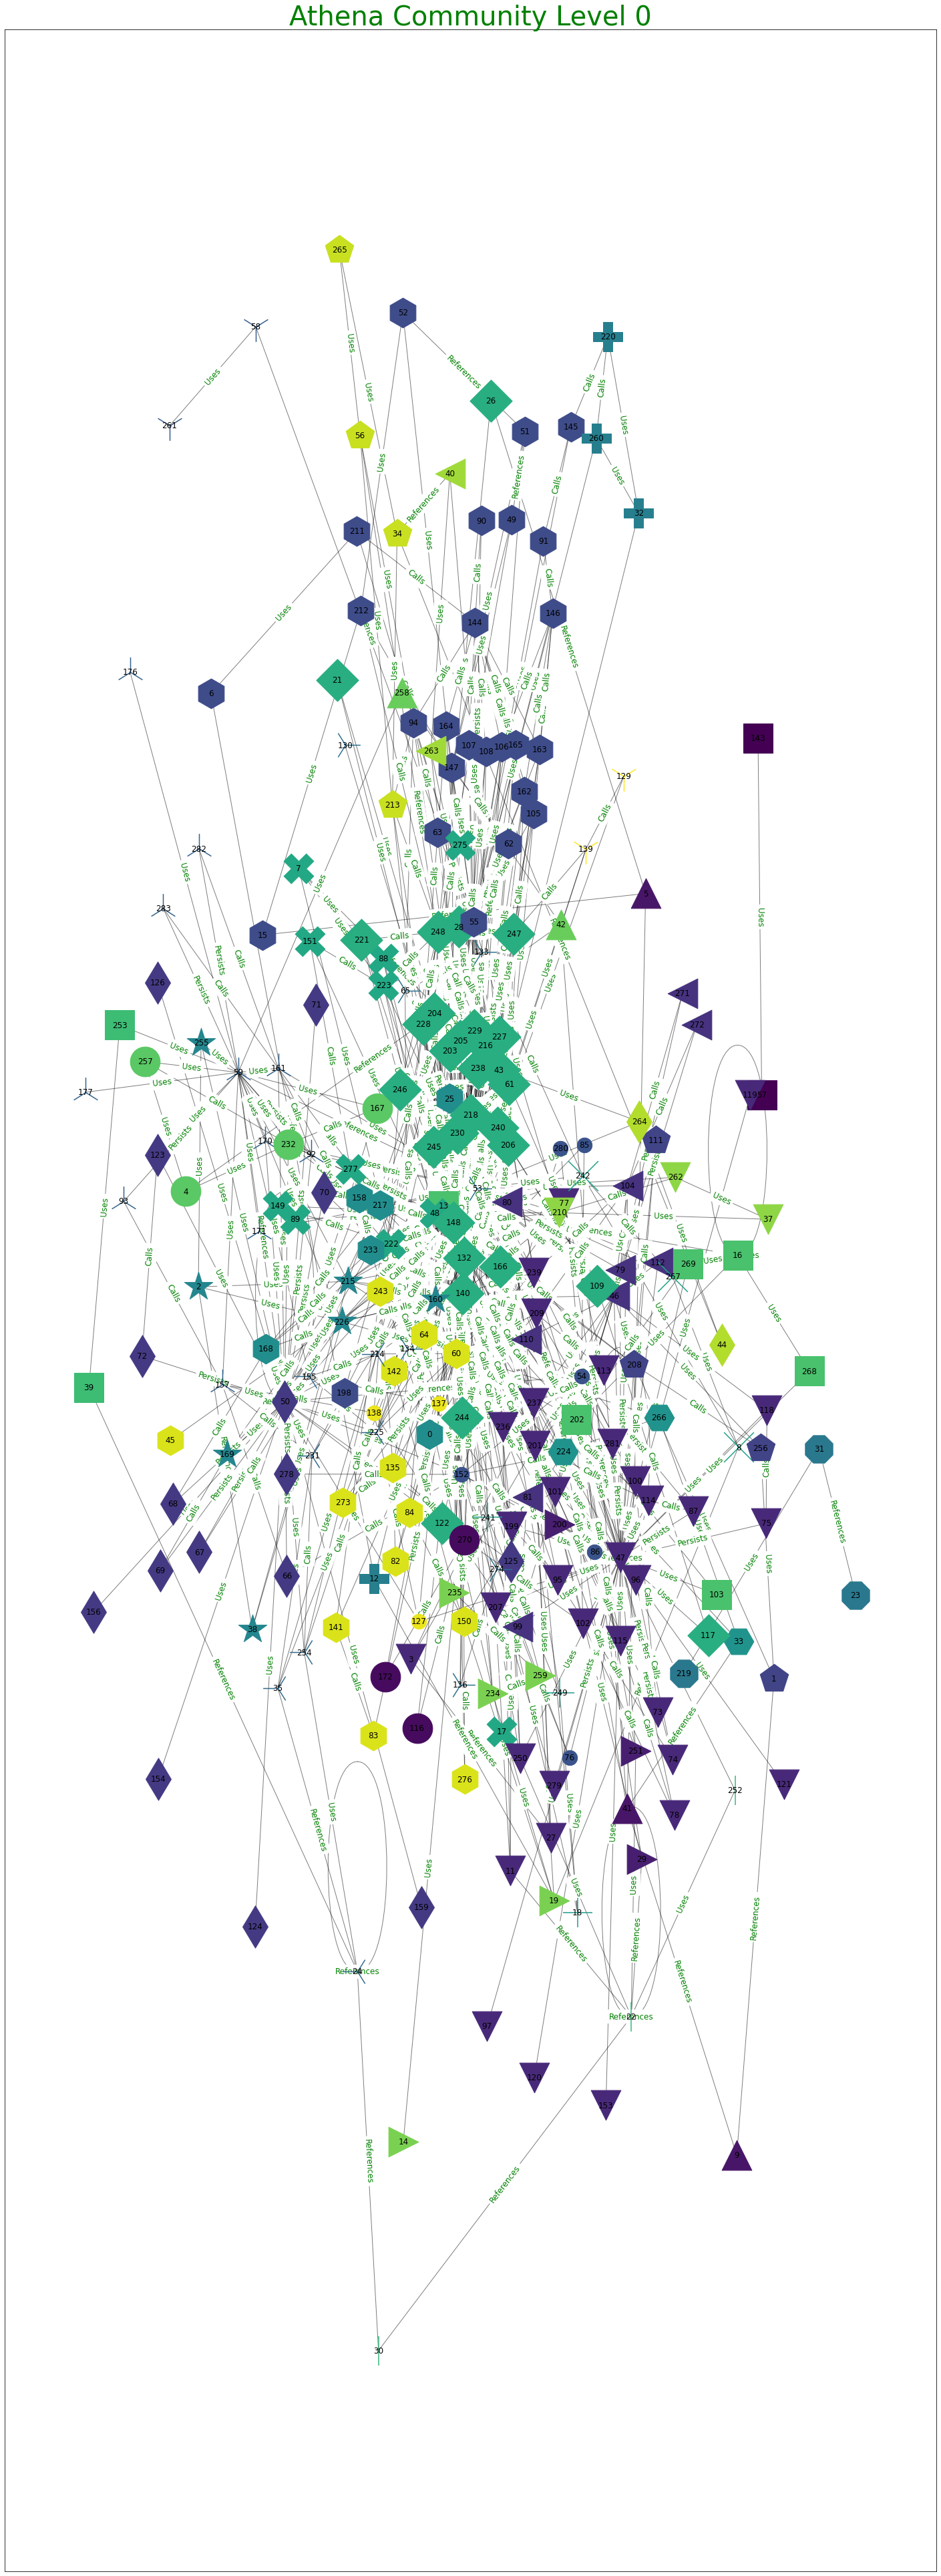

In [19]:
#draw_graph(athenaPart0,"Athena Community Level 0",None)
draw_community(G,athenaPart0,"Athena Community Level 0")

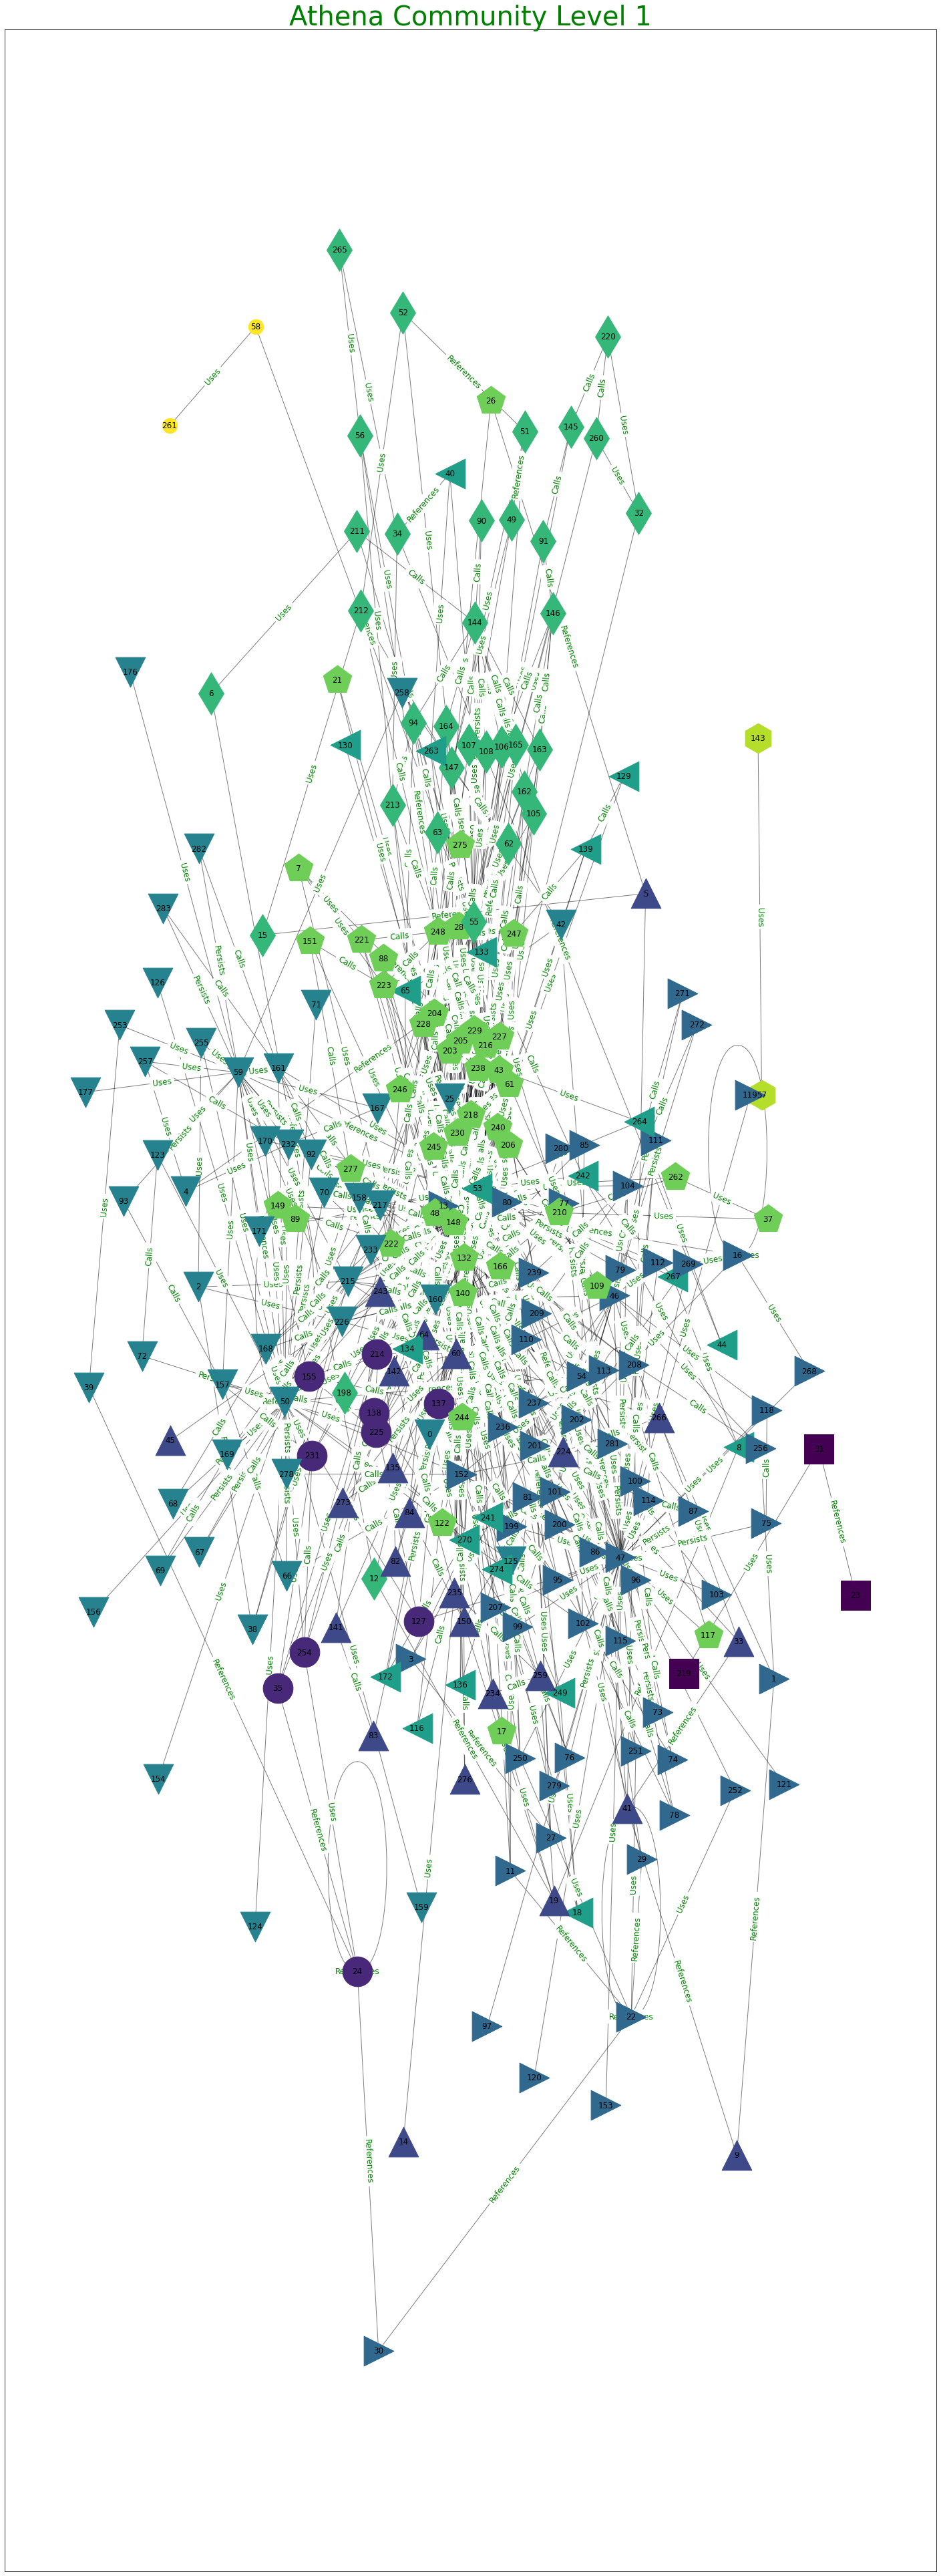

In [23]:
#draw_graph(athenaPart1,"Athena Community Level 1",None)
draw_community(G,athenaPart1,"Athena Community Level 1")

#### 1.2.3 save louvain dendogram to excel wrt levels

In [24]:
#convert the partition dictionary to the dataframe
athenaPart0_df = pd.DataFrame([athenaPart0])
athenaPart1_df = pd.DataFrame([athenaPart1])
athenaPart2_df = pd.DataFrame([athenaPart2])

#write to the excel each partition on each sheet
with pd.ExcelWriter('GL10appsDataGraphs/Louvain-AthenaCommunity.xlsx') as writer:  
    athenaPart0_df.to_excel(writer, sheet_name='AthenaL0')
    athenaPart1_df.to_excel(writer, sheet_name='AthenaL1')
    athenaPart2_df.to_excel(writer, sheet_name='AthenaL2')